# Staying Afloat: Risk, Ruin, and Resilience in Flood Insurance
### A study of the Cramér-Lundberg model and its discounted extension

You run an insurance company. Your clients are homeowners exposed to flood risk. They pay a steady premium, and in return, you cover the damage when the water rises. Premiums flow in smoothly. Claims arrive randomly, sometimes catastrophically. The question is simple to state and hard to answer. Can this asymmetry drive you to ruin?

One caveat upfront. Flood risk is inherently *systematic*. When a river bursts its banks, entire neighbourhoods flood at once. We are not modelling a small local insurer covering a single village. We assume a large, geographically diversified portfolio where claims can reasonably be treated as independent. Within that scope, the Cramér-Lundberg model is both mathematically coherent and economically meaningful.

This report follows the questions a manager would naturally ask. Is the business viable on average ? What is the actual probability of bankruptcy ? How much does initial capital matter ? And what changes when the model accounts for the time value of money ?

## The Model

The reserve of the company at time $t$ is:

$$R_{t}=u+pt-\sum_{i=1}^{N_{t}}Y_{i}$$

**$u \geq 0$**  the initial capital.

**$p > 0$**  the premium rate, collected continuously.

**$N_t$**the number of claims that have occurred in $[0, t]$, following a homogeneous Poisson process with intensity $\mu > 0$.

**$(Y_i)_{i \geq 1}$** are i.i.d. positive random variables representing claim severities, with mean $m = \mathbb{E}[Y_1]$. In our numerical experiments, $Y_i \sim \mathcal{E}(\beta)$ so that $m = 1/\beta$.

The sum $\sum_{i=1}^{N_t} Y_i$ is a compound Poisson process. The reserve is simply initial capital plus premium income, minus total claims paid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulation_richesse(mu,T,beta,u,n,theta):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

Before any analysis, it is worth simply watching the reserve evolve. The pattern is immediate: steady growth between claims, sudden drops when they hit. That tension is what the rest of this report will quantify. Specifically, how often do the drops drag reserve below zero ?

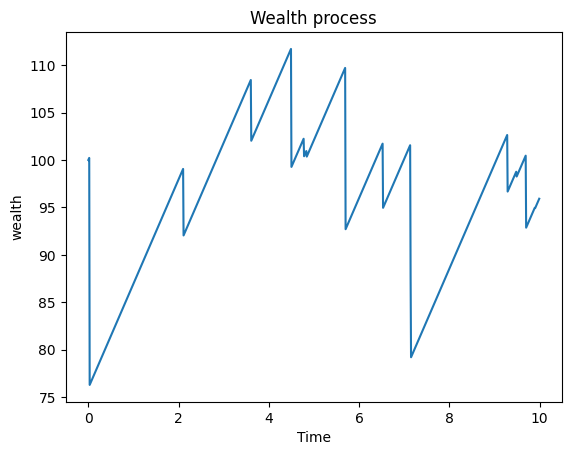

In [3]:
mu=1
T=10
beta=0.1
theta=0.1
n=100
u=100
t,Rt=simulation_richesse(mu,T,beta,u,n,theta)
plt.plot(t,Rt)
plt.title("Wealth process")
plt.xlabel("Time")
plt.ylabel("wealth")
plt.show()

## Risk Analysis in the Classical Model

The reserve process is now defined. The manager's first, most pressing question is blunt: **is this business sustainable ?** Not in some vague qualitative sense, but in a precise mathematical one. Two sub-questions structure the entire analysis.

### 1. Is the company profitable on average ?

Before worrying about extreme events, we should understand the *expected* trajectory of the reserve. If $\mathbb{E}[R_t]$ is declining over time, the company is losing money on average , and no amount of initial capital will save it in the long run. The first task is therefore to derive an explicit formula for $\mathbb{E}[R_t]$, and to identify the **critical premium rate** $p^*$ below which the expected reserve eventually turns negative. This threshold separates two economic regimes: one where the company is structurally profitable, and one where it is structurally doomed.

In [4]:
def simulation_richesse(mu,T,beta,u,n,theta):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

**Computing $\mathbb{E}[R_t]$.**
By linearity of expectation,
$$\mathbb{E}[R_{t}] = \mathbb{E}[u + pt] - \mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right] = u + pt - \mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right].$$
The compound Poisson sum is handled by Wald's identity: since $N_t \sim \mathcal{P}(\mu t)$ and the $Y_i$ are i.i.d. with mean $m$,
$$\mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right] = \mathbb{E}[N_t] \cdot \mathbb{E}[Y_1] = \mu t \cdot m.$$
$$\boxed{\mathbb{E}[R_{t}] = u + (p - \mu m)\,t.}$$

**Finding the critical threshold $p^*$.**
For $\mathbb{E}[R_t] > 0$ to hold for all $t \geq 0$, the drift must be strictly positive:
$$p - \mu m > 0 \implies p > \mu m.$$
Since $u \geq 0$, the initial condition is automatically satisfied. The critical premium rate is therefore:
$$\boxed{p^* = \mu m.}$$

The reserve drifts linearly in time at rate $p - \mu m$, where $\mu m$ is the average claim burden per unit time. This threshold separates two regimes: below $p^*$ the reserve erodes on average, above it the company is structurally profitable. Notice that $p^*$ does not depend on $u$. Initial capital buys time, not viability. In practice, insurers set $p = (1 + \theta)\,p^*$ where $\theta > 0$ is the **safety loading**, the markup above break-even.

### 2. But is a positive expected trend enough?

Here is the uncomfortable truth : a favorable expected drift is not the same as safety. Even with $p > p^*$, random fluctuations can push the reserve into negative territory , ruin , at any point in time. The expected value tells us where the process is going on average, it says nothing about the volatility of individual trajectories around that average.

The regulator therefore asks a different, sharper question: **what is the probability that the company actually goes bankrupt before the end of the contract ?** 

Formally, this is $\mathbb{P}[\exists\, t \leq T,\, R_t < 0]$. 

**Numerical setup.** The parameters are now fixed throughout the rest of Part 1:

| Parameter | Value | Interpretation |
|-----------|-------|----------------|
| $T$ | $100$ | Long-term contract horizon |
| $\mu$ | $1$ | One flood event per unit time on average |
| $\beta$ | $0.1$ | Claims are exponential with mean $m = 1/\beta = 10$ |
| $\theta$ | $30\%$ | Safety loading above break-even |
| $p$ | $(1+\theta)\mu m = 13$ | Premium rate, safely above $p^* = 10$ |

The only free parameter in what follows is the initial capital $u$, which we will vary systematically to understand how much it actually protects the company.

In [5]:
##"Estimation of Rt"
def estimation_ruine(mu,T,beta,u,theta,n) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        #print(Nt)
        #print(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        #print(Y)
        sinistres=np.cumsum(Y)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

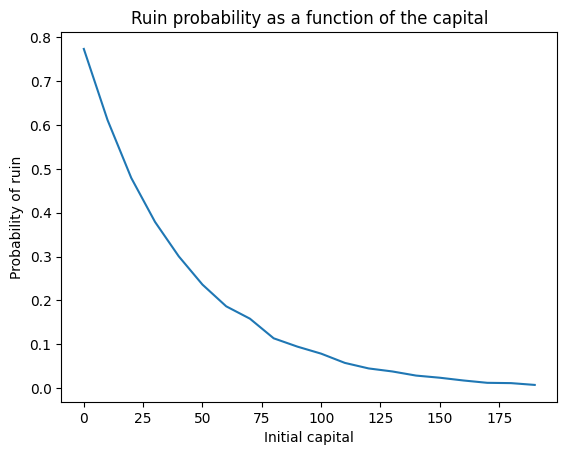

In [6]:
##"Ruin probability as a function of the capital"
mu=1
T=100
beta=0.1
theta=0.3
n=10000
proba_ruine=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)

plt.plot(u,proba_ruine)
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Probability of ruin")
plt.show()

The curve tells a clear story. Ruin probability does not merely decrease with $u$, it decreases **exponentially fast**. 

This means that each additional unit of capital reduces risk by a constant multiplicative factor, not a constant additive one. Capital is therefore a highly efficient protection mechanism.

This suggests fitting the empirical curve to:
$$\mathbb{P}[\mathcal{R}=1] \approx \exp(-\kappa u),$$
where $\kappa > 0$ is the **decay rate**. A larger $\kappa$ means the same safety level is achieved with less capital. Estimating $\kappa$ from the log-linearised curve is straightforward.

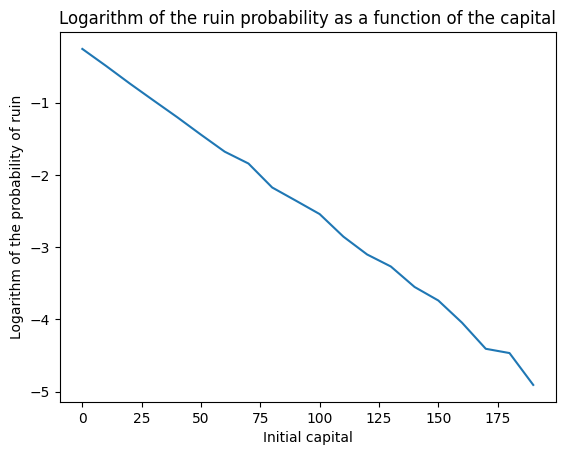

-0.028388633494150432


In [7]:
##"Estimation of k"
log_proba_ruine=np.log(proba_ruine)
plt.plot(u,log_proba_ruine)
plt.title("Logarithm of the ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Logarithm of the probability of ruin")
plt.show()
kappa=np.mean(log_proba_ruine[1:20]/u[1:20])
print(kappa)

The log-ruin probability is linear in $u$, confirming the exponential decay hypothesis. Starting from $\mathbb{P}[\mathcal{R}=1] \approx e^{-\kappa u}$, taking the logarithm gives $\log \mathbb{P}[\mathcal{R}=1] \approx -\kappa u$, so $\kappa$ is estimated by averaging the ratios $\log \hat{p}(u_k) / u_k$, with $(u_k \neq 0) $ . We can now overlay the fitted curve against the Monte-Carlo estimates:

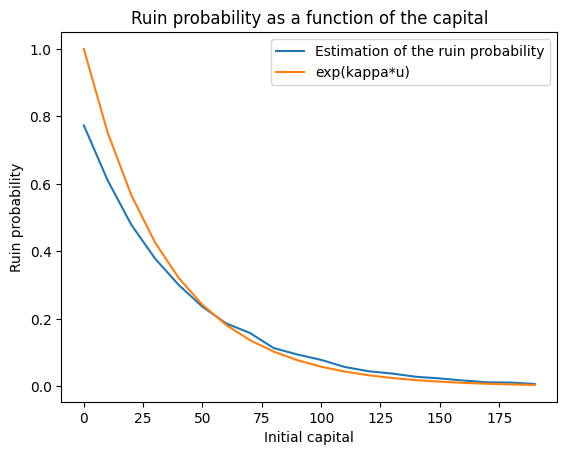

In [8]:
##"Comaparaison Estimation and exponential model "
plt.plot(u,proba_ruine,label="Estimation of the ruin probability")
plt.plot(u,np.exp(kappa*u),label="exp(kappa*u)")
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Ruin probability")
plt.legend()
plt.show()

---

## Part 2 - The Discounted Cramér-Lundberg Model

The classical model treats all claims equally regardless of when they occurred. A claim filed yesterday and a claim filed ten years ago weigh identically on today's reserve. But money has a time value. A euro promised in the future isn't worth the same as a euro today, and the same logic applies to past liabilities. The discounted model accounts for this by weighting each claim by how long ago it arrived:

$$R_t = u + pt - \sum_{i=1}^{N_t} e^{-\rho(t - \tau_i)} Y_i, \quad t \geq 0 \tag{2}$$

where $\rho \geq 0$ is the discount rate and $\tau_i$ is the arrival time of claim $i$. The factor $e^{-\rho(t-\tau_i)}$ equals 1 for a brand-new claim and decays towards 0 as the claim ages. Setting $\rho = 0$ recovers model (1) exactly.

### 1. Is the company profitable on average ?

The discount factors $e^{-\rho(t-\tau_i)}$ couple claim amounts to their arrival times, which makes the calculation of $\mathbb{E}[R_t]$ more involved than in the classical case.

**Step 1. Linearity of expectation.**

$$\mathbb{E}[R_t] = u + pt - \mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}Y_i\right].$$

The whole difficulty lies in the last term.

**Step 2. Separating claims from arrival times.**

Conditioning first on $N_t = n$ and on the arrival times $\tau_1, \dots, \tau_n$, the independence of the $Y_i$ from the Poisson process gives:

$$\mathbb{E}\left[\sum_{i=1}^{n} e^{-\rho(t-\tau_i)}Y_i \;\middle|\; N_t = n,\, \tau_1,\dots,\tau_n\right] = m\sum_{i=1}^{n} e^{-\rho(t-\tau_i)}.$$

Taking the expectation over the arrival times then yields:

$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}Y_i\right] = m\,\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right].$$

**Step 3. Conditioning on $N_t$.**

By the law of total expectation:

$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right] = \sum_{n=0}^{\infty} \mathbb{E}\left[\sum_{i=1}^{n} e^{-\rho(t-\tau_i)} \,\middle|\, N_t=n\right]\mathbb{P}(N_t=n).$$

A classical result states that, given $N_t = n$, the arrival times $\tau_1, \dots, \tau_n$ are distributed as the order statistics of $n$ i.i.d. uniform random variables on $[0, t]$. Denoting $U \sim \mathcal{U}([0,t])$:

$$\mathbb{E}\left[\sum_{i=1}^{n} e^{-\rho(t-\tau_i)} \,\middle|\, N_t=n\right] = n\,\mathbb{E}\left[e^{-\rho(t-U)}\right] = \frac{n}{t}\int_0^t e^{-\rho(t-s)}\,ds.$$

**Step 4. Removing the conditioning.**

Substituting back and recognising $\sum_{n=0}^{\infty} n\,\mathbb{P}(N_t=n) = \mathbb{E}[N_t] = \mu t$:

$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right] = \mu \int_0^t e^{-\rho(t-s)}\,ds.$$

**Closed-form result.**

Computing the integral via the substitution $v = t - s$:

$$\boxed{\mathbb{E}[R_t] = u + pt - \frac{\mu m}{\rho}\left(1 - e^{-\rho t}\right)} \quad (\rho > 0).$$

Setting $\rho = 0$ recovers the classical result $\mathbb{E}[R_t] = u + pt - \mu m t$, as expected.

The key difference with model (1) is that the expected claim burden $\frac{\mu m}{\rho}(1 - e^{-\rho t})$ now saturates toward $\frac{\mu m}{\rho}$ as $t \to \infty$, while premium income $pt$ keeps growing. The financial risk is therefore concentrated in the short term, before discounting has had time to neutralise the claim burden.

### Does the Safety Threshold Change?

We now determine the critical premium rate $p^*$ below which the company's expected wealth can become negative , even temporarily.

**Convexity of the expected wealth.**
We differentiate $t \mapsto \mathbb{E}[R_t]$:
$$\frac{d}{dt}\mathbb{E}[R_t] = p - \mu m\, e^{-\rho t}.$$
The second derivative is
$$\frac{d^2}{dt^2}\mathbb{E}[R_t] = \mu m \rho\, e^{-\rho t} > 0 \quad \text{for all } t \geq 0,$$
so $t \mapsto \mathbb{E}[R_t]$ is **strictly convex**, and any critical point is necessarily a global minimum. This convexity has a concrete meaning: the expected drain from claims is heaviest at the start and slows down as discounting takes effect. The company's expected trajectory first dips, then recovers.

**Case $p \geq \mu m$.**
The first derivative is non-negative for all $t \geq 0$, so $\mathbb{E}[R_t]$ is non-decreasing. Since $\mathbb{E}[R_0] = u \geq 0$, the reserve remains non-negative in expectation for all time.

**Case $p < \mu m$.**

When the premium is insufficient to cover the average claim rate, the reserve does not grow monotonically. The derivative $\frac{d}{dt}\mathbb{E}[R_t] = p - \mu m\, e^{-\rho t}$ starts negative and only becomes positive once discounting has sufficiently reduced the claim burden. This means $\mathbb{E}[R_t]$ first decreases, reaches a minimum, then recovers. The question is: **does this minimum dip below zero?**

**Finding the minimum.** Setting the derivative to zero gives the unique critical point:

$$t^* = \frac{1}{\rho}\ln\!\left(\frac{\mu m}{p}\right) > 0$$

Since the second derivative is positive, this is a global minimum. Evaluating $\mathbb{E}[R_{t^*}]$ using $e^{-\rho t^*} = \frac{p}{\mu m}$:

$$\mathbb{E}[R_{t^*}] = u + \underbrace{\frac{p}{\rho}\ln\!\left(\frac{\mu m}{p}\right) - \frac{\mu m - p}{\rho}}_{\displaystyle=:\,\Delta}$$

**Signing the bracket $\Delta$.** We claim $\Delta < 0$, i.e.:

$$p\ln\!\left(\frac{\mu m}{p}\right) < \mu m - p$$

Setting $x = \frac{\mu m}{p} > 1$, this reduces to $\ln(x) < x - 1$. Define $g(x) = x - 1 - \ln(x)$. Then $g(1) = 0$ and $g'(x) = 1 - \frac{1}{x} > 0$ for all $x > 1$, so $g$ is strictly increasing, giving $g(x) > 0$ for all $x > 1$. Hence $\Delta < 0$.

**Answering the question.** Since $\Delta < 0$, whether $\mathbb{E}[R_{t^*}] > 0$ depends entirely on whether $u$ is large enough to offset it:

- If $u > |\Delta|$: the initial capital absorbs the dip and $\mathbb{E}[R_t] > 0$ for all $t$.
- If $u = 0$: there is no cushion and $\mathbb{E}[R_{t^*}] = \Delta < 0$ , **ruin in expectation is unavoidable**, regardless of discounting.

Therefore, the sign of $\mathbb{E}[R_{t^*}]$ depends on whether 
$u > |\Delta|$. An insurer with sufficient capital can survive the dip, 
but one with $u = 0$ cannot. Therefore, when $p < \mu m$, there is no 
premium condition alone that guarantees $\mathbb{E}[R_t] > 0$ for all $t$ 
**universally across all initial capitals** , solvency in expectation 
becomes a joint condition on both $p$ and $u$, not on pricing alone.

This is precisely why we require $p > \mu m$: it is the unique threshold 
that guarantees $\mathbb{E}[R_t] > 0$ for all $t$, for **any** $u \geq 0$, 
with no dependence on capitalisation. Hence $p^* = \mu m$.

**Conclusion.**
The condition $\mathbb{E}[R_t] > 0$ for all $t \geq 0$ is guaranteed if and only if $p > \mu m$, regardless of $u$. The critical premium rate is:

$$\boxed{p^* = \mu m = \frac{\mu}{\beta}.}$$

This result carries a striking message: **discounting does not change the break-even condition**. The critical premium is identical to that of the classical model , a fact confirmed by letting $\rho \to 0$: using $e^{-\rho t} \approx 1 - \rho t$, we get $\frac{\mu m}{\rho}(1 - e^{-\rho t}) \to \mu m t$, recovering $p^* = \mu m$.

**A key qualitative difference.**
Although the critical threshold is the same, the behaviour *below* $p^*$ changes fundamentally. In the classical model, $\mathbb{E}[R_t] \to -\infty$ when $p < p^*$ , the company is structurally doomed in the long run. In the discounted model, the total discounted claims are bounded:
$$\frac{\mu m}{\rho}(1 - e^{-\rho t}) \xrightarrow[t \to \infty]{} \frac{\mu m}{\rho} < +\infty,$$
so $\mathbb{E}[R_t] \to +\infty$ regardless of $p$. The company always recovers eventually , but it may go through a dangerous valley early on, near $t^*$, before discounting has had time to neutralise the claim burden. In the discounted world, **short-term liquidity is the real threat, not long-run solvency**.

### Simulating the Discounted Reserve

With the theory settled, we turn to simulation to see these effects in practice. The logic mirrors the classical case exactly, with one modification: at each time step $t_i$, instead of summing all past claims at face value, we weight each claim $Y_j$ by $e^{-\rho(t_i - \tau_j)}$ , a factor that shrinks the older the claim is. Parameters are kept identical to Part 1 ($T = 100$, $\mu = 1$, $\beta = 0.1$, $\theta = 30\%$, $m = 10$, $p^* = 10$) so that comparisons are meaningful.

In [9]:
def simulation_discounted(mu,T,beta,u,n,theta,rho):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    exp=np.exp(rho*temps_arrivee)
    coefs_somme=np.array(Y)*np.array(exp)
    sinistres=np.cumsum(coefs_somme)
    #Rt=u+p*t-np.exp(-rho*t)*np.cumsum(np.exp(rho*np.array(temps_arrivee[temps_arrivee<=t]))*np.array(Y[temps_arrivee<=t]))
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(np.exp(-rho * (ti - temps_arrivee[mask])) * Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

The function `simulation_discounted` adapts `simulation_richesse` to the discounted setting. The structural logic is identical , sample $N_t \sim \mathcal{P}(\mu T)$ arrivals, draw their times uniformly and sort them, draw exponential claim amounts , but the inner loop now computes the **discounted aggregate** at each time step $t_i$:

$$\sum_{j\,:\,\tau_j \leq t_i} e^{-\rho(t_i - \tau_j)}\, Y_j$$

rather than the raw cumulative sum $\sum_j Y_j$. This is implemented by applying `np.exp(-rho * (ti - temps_arrivee[mask]))` as a weight vector to the claim amounts before summing. The older a claim, the smaller its weight , which is exactly the discounting mechanism of model (2).

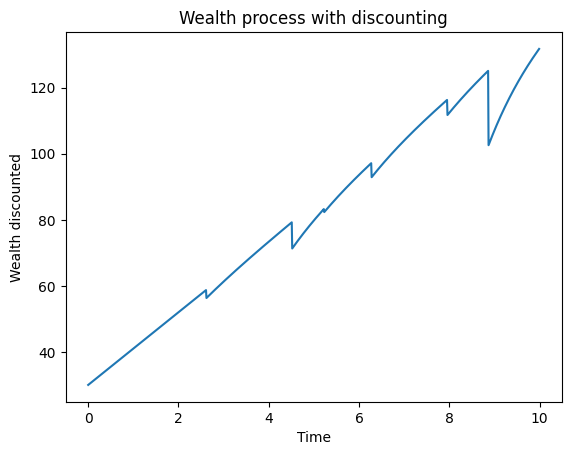

In [10]:
mu=1
T=10
beta=0.1
theta=0.1
n=100
rho=1
u=30
t,Rt=simulation_discounted(mu,T,beta,u,n,theta,rho)
plt.plot(t,Rt)
plt.title("Wealth process with discounting")
plt.xlabel("Time")
plt.ylabel("Wealth discounted")
plt.show()

Comparing this trajectory to the classical model is instructive. In model (1), each claim event causes an instantaneous downward jump of the full amount $Y_i$, which persists indefinitely in the reserve computation. In model (2), a large flood that occurred early gradually fades from the balance sheet as $e^{-\rho(t-\tau_i)} \to 0$, giving the process a smoother long-run profile. For large $\rho$, past claims become negligible very quickly and the reserve essentially grows at rate $p$ in the long run , a numerical illustration of the theoretical result that financial risk concentrates in the short term.

### How Does Discounting Affect the Risk of Ruin?

The theoretical analysis told us that $p^*$ is unchanged. But does discounting actually make the company *safer* in practice ? 

In math terms, does it reduce the ruin probability for a given initial capital $u$? Intuitively, the answer should be yes. By shrinking the effective weight of past claims, discounting reduces the total pressure on the reserve, making ruin harder to reach.

We estimate the ruin probability using the same Monte-Carlo approach as in Part 1. The ruin check at each claim time $\tau_j$ is adapted to account for discounting.

The effective liability at time $\tau_j$ is the discounted sum $e^{-\rho \tau_j} \sum_{k \leq j} e^{\rho \tau_k} Y_k$, computed incrementally from the cumulative sums of the weighted amounts $e^{\rho \tau_k} Y_k$.

In [11]:
def estimation_ruine_discounted(mu,T,beta,u,theta,n,rho) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        exp=np.exp(rho*temps_arrivee)
        coefs_somme=np.array(Y)*np.array(exp)
        sinistres=np.cumsum(coefs_somme)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-np.exp(-rho*temps_arrivee[j])*sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

We fix $\rho = 0.1$ and compute the ruin probability for $u \in \{0, 10, 20, \ldots, 190\}$ using $n = 1\,000$ Monte-Carlo replications per value. All other parameters remain unchanged from Part 1.

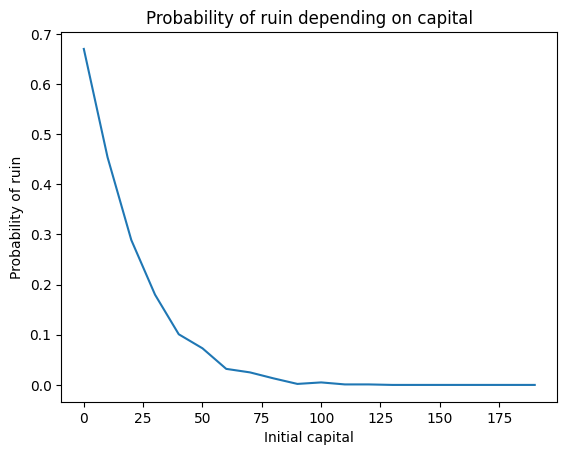

In [12]:
mu=1
T=100
beta=0.1
theta=0.3
n=1000
rho=0.1
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine_discounted)
plt.title("Probability of ruin depending on capital")
plt.xlabel("Initial capital")
plt.ylabel("Probability of ruin")
plt.show()

### Validation: Recovering the Classical Model at $\rho \to 0$

Before drawing conclusions, we should verify that our implementation is correct. A natural sanity check is to set $\rho$ to a very small value , say $\rho = 0.001$ , and confirm that the discounted model reproduces the classical results. At such a small discount rate, $e^{-0.001(t-\tau_i)} \approx 1$ for all claim ages in $[0, T = 100]$, so the two models should be nearly indistinguishable.

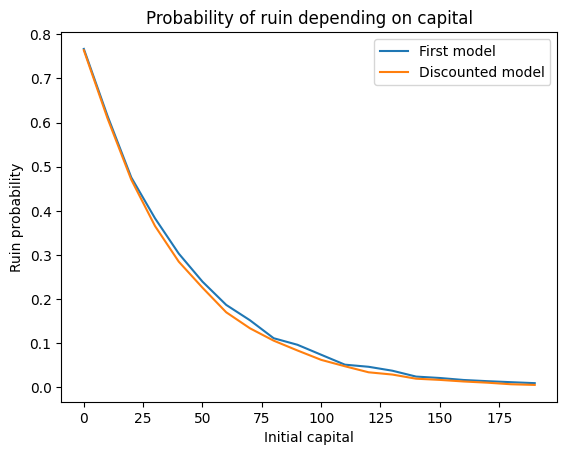

In [13]:
mu=1
T=100
beta=0.1
theta=0.3
n=10000
rho=0.001
proba_ruine=np.zeros(20)
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine,label='First model')
plt.plot(u,proba_ruine_discounted,label='Discounted model')
plt.title("Probability of ruin depending on capital")
plt.xlabel("Initial capital")
plt.ylabel("Ruin probability")
plt.legend()
plt.show()

The two curves overlap almost perfectly , a reassuring numerical confirmation that the discounted model converges to the classical one as $\rho \to 0$, and that our implementation faithfully captures the theoretical relationship between the two frameworks.

### Does the Exponential Fit Still Hold Under Discounting?

In the classical model, the exponential decay $\hat{p}(u) \approx e^{-\kappa u}$ has a 
rigorous theoretical foundation. In the discounted model, no such guarantee exists: claims 
no longer hit the reserve with equal weight, and the mathematical argument breaks down. 
Whether exponential decay still holds empirically is an open question that depends on the 
parameters, particularly $\rho$. For small $\rho$ the two models are close and the fit 
remains approximately valid. For larger $\rho$ the behavior may differ. An additional 
practical obstacle is that discounting reduces the ruin probability so drastically that 
beyond a moderate capital level, none of our $n = 5000$ simulations produce a ruin event, 
making $\log \hat{p}(u)$ undefined and any exponential fit impossible to compute reliably. 
We therefore do not attempt to fit a decay rate in the discounted setting, and limit our 
analysis to the direct comparison of ruin probabilities across capital levels and discount rates.

### How Much Does the Discount Rate Matter?

The natural next question is quantitative: how sensitive is the ruin probability to the choice of $\rho$? We test four values spanning two orders of magnitude , $\rho \in \{0.01, 0.1, 1, 5\}$ , and observe how the ruin curve shifts as discounting becomes more aggressive. The prediction from the theory is clear: higher $\rho$ means faster neutralisation of past claims, hence lower ruin probability and steeper exponential decay in $u$.

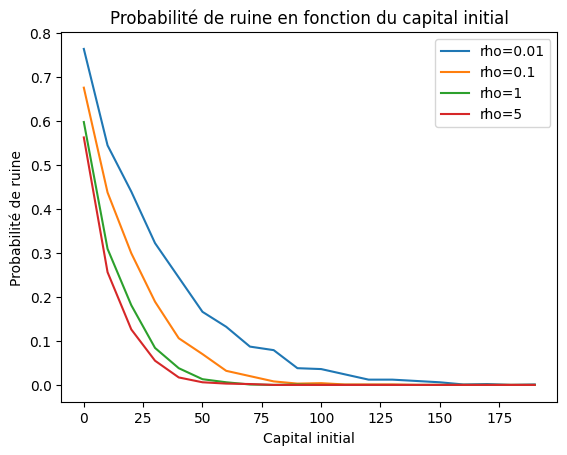

In [15]:
mu=1
T=100
beta=0.1
theta=0.3
n=1000
proba_ruine_1=np.zeros(20)
proba_ruine_2=np.zeros(20)
proba_ruine_3=np.zeros(20)
proba_ruine_4=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_1[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.01)
    proba_ruine_2[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.1)
    proba_ruine_3[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=1)
    proba_ruine_4[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=5)
    

plt.plot(u,proba_ruine_1,label='rho=0.01')
plt.plot(u,proba_ruine_2,label='rho=0.1')
plt.plot(u,proba_ruine_3,label='rho=1')
plt.plot(u,proba_ruine_4,label='rho=5')
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()

### What Have We Learned?

This report set out to answer a single question from the manager's perspective: can the asymmetry 
between smooth premium income and sudden random claims drive the company to ruin, and what can 
be done about it?

**Pricing is the first line of defence.** Both models share the same critical threshold 
$p^* = \mu m$. Below it, no amount of initial capital can guarantee a positive expected reserve 
for every possible starting position. Above it, the expected reserve grows indefinitely. This is 
not a model-specific result but a fundamental accounting identity: premium income must cover 
expected claim costs, and discounting does not change that arithmetic.

**Capital is the second line of defence, and it is highly efficient.** In the classical model, 
the ruin probability decays exponentially in $u$. Each additional unit of capital reduces risk 
by a constant multiplicative factor rather than a constant additive one, which means capital 
provides rapidly increasing protection. The fitted decay rate $\kappa$ quantifies precisely how 
efficient this protection is for a given set of parameters.

**Discounting makes the company structurally safer, but changes the nature of the risk.** As 
$\rho$ increases, ruin probabilities fall across all capital levels. In the limit $\rho \to \infty$, 
past claims vanish instantly and ruin becomes impossible. The practical implication is that in 
high interest rate environments, or when claims are settled quickly, the company needs less 
initial capital to achieve the same level of safety. However, the exponential relationship 
between capital and ruin probability that held in the classical model breaks down under 
discounting. Claims no longer hit the reserve with equal weight, their impact depends on when 
they arrived, and the clean mathematical structure that produced exponential decay no longer 
applies.

**Discounting also shifts the nature of the risk in time.** In the classical model, an 
underpriced company is structurally doomed: its expected reserve drifts to $-\infty$ and the 
threat of ruin never disappears. In the discounted model, the expected reserve always recovers 
eventually, but passes through a dangerous early window near $t^*$ before discounting has had 
time to neutralise the claim burden. The threat is concentrated at the start of the contract, 
not spread across its entire duration.

**The central message for the flood insurer is therefore the following.** Set the premium above 
$\mu m$, hold enough initial capital to survive the early phase of the contract, and let the 
time value of money work in your favour. A company that prices correctly and weathers its first 
years of operation is, in the long run, structurally safe.